# Computational Practicum Q2 Mock Exam

### General Guidelines

> ⚠️⚠️⚠️ READ CAREFULLY ⚠️⚠️⚠️

- __ACROSS THE EXAM YOU WILL BE ASKED TO STORE YOUR SOLUTIONS IN A VARIABLES OF THE SPECIFIC NAMES. PLEASE MAKE SURE YOU NAME THEM CORRECTLY, ACCORDING TO THE INSTRUCTIONS AND DO NOT CHANGE NAMES OF FUNCTIONS AND/OR VARIABLES ALREADY STATED.__
- Do not add, delete or create cells, write the answer only in the space marked with the three dots (`...`). Where function skeletons are provided, it is assumed that that function can be called again with different inputs somewhere else. So be careful to write code outside of functions.
- Read carefully what is required to be printed/returned/plotted in the answer. Please do not output what is not asked for. 
  - If you used the print function inside functions for debugging, comment it out ( Ctlr + / ) before submitting.
- All plots should have title, xlabel, ylabel, and legend (if there are more than one curve on the plot).
- All functions should have type hints and descriptive docstrings.
- Please read the error messages if you get any, and try to understand what they mean.
- You can use `%debug` to start an IPython console in a cell (or a scratchpad cell!) after an exception has occurred to try to debug.
- You can use `%pdb` to toggle the Python DeBugger (pdb) auto start after an unhandled exception.
- In the exam you will NOT find public tests, no hint is given to verify your solution.
- Please use the documentation you are provided with. It contains information about the Python commands and eventual packages' functions.
- ⚠️ __BEFORE YOU SUBMIT, RESTART THE KERNEL AND RE-RUN ALL, TO MAKE SURE ALL STILL WORKS!__

### How to submit the Coding Exam (Jupyter Notebook)
- Check that your notebook is in the P: drive.
- Check that a single notebook is in the P: drive. Redundant copies must be deleted.
- The Jupyter Notebook saves automatically. You can check the last saving time from the File Explorer. You can consider to save manually as well for redundancy: File -> Save
- Close all the windows and log out from the computer. **We will collect your notebook automatically from the P: drive if everything above is done correctly**

In [1]:
import math
from typing import Callable, List, Tuple, Union

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

print("Finished importing packages")

Finished importing packages


## Part 1: Advanced programming

### Question 1.1: Testing the ideal_molar_volume function

Given below is a function `ideal_molar_volume` that calculates the molar specific volume of an ideal gas when given the gas' pressure in bar and temperature in K.

Write a test function named `test_ideal_molar_volume()` that verifies the following with assert statements:

1. That the function returns `None` if `P_bar` is negative (with a valid input for `T_K`).
2. That the function returns `None` if `T_K` is negative (with a valid input for `P_bar`).
3. That the function returns the correct molar specific volume when given valid input, for example: `P_bar = 1` and `T_K = 298.15`. 

You may assume `P_bar = 1 bar` and `T_K = 298.15 K` yields approximately `(8.314 * 298.15) / 100000` m³/mol. Also, assume an absolute tolerance of `0.001` when comparing the outputs.

In [2]:
def ideal_molar_volume(P_bar: float, T_K: float) -> float:
    """
    Calculate the molar specific volume of an ideal gas. If P_bar or T_k are
    negative, None is returned.

    Parameters:
        P_bar (float): Pressure in bar
        T_K (float): Temperature in Kelvin

    Returns:
        float: Molar specific volume in m^3/mol
    """
    # Check for negative, invalid inputs.
    if P_bar <= 0 or T_K <= 0:
        return None

    R_u = 8.314  # J/(mol·K)
    # Convert pressure from bar to Pa
    P_pa = P_bar * 1e5

    # Calculate molar specific volume using v = (R_u * T) / P
    v = (R_u * T_K) / P_pa
    return v

In [3]:
def test_ideal_molar_volume():
        
        valid_T = 298.15
        invalid_T = -298.15
        valid_P = 1
        invalid_P = -1

        act_val = (8.314 * 298.15) / 100000
        func = ideal_molar_volume(1, 298.15)  

        assert ideal_molar_volume(invalid_P, valid_T) == None,\
                "Code running for negative P_bar input"
        
        assert ideal_molar_volume(valid_P, invalid_T) == None,\
                "Code running for negative T_K values"
        
        assert abs(act_val-func) < 0.001,\
                "The value does not converge the the theoretical value " 


In [4]:
test_ideal_molar_volume()

### Question 1.2: Organic mixture

Below is the definition of the class `OrganicMolecule`, which represents an organic molecule with carbon, oxygen, and hydrogen atoms. The OrganicMolecule also calculates the molecular weight in $g/mol$ with it's `calculate_molar_weight` method.

In [5]:
class OrganicMolecule:
    """
    A class to represent an organic molecule composed of carbon, oxygen, and hydrogen atoms.

    Attributes:
        name (str): The name of the compound
        no_carbon_atoms (int): Number of carbon atoms in the molecule.
        no_oxygen_atoms (int): Number of oxygen atoms in the molecule.
        no_hydrogen_atoms (int): Number of hydrogen atoms in the molecule.
    """

    def __init__(
        self,
        name: str,
        no_carbon_atoms: int,
        no_oxygen_atoms: int,
        no_hydrogen_atoms: int,
    ) -> None:
        """
        Initializes an OrganicMolecule instance.

        Args:
            name (str): The name of the compound
            no_carbon_atoms (int): Number of carbon atoms in the molecule.
            no_oxygen_atoms (int): Number of oxygen atoms in the molecule.
            no_hydrogen_atoms (int): Number of hydrogen atoms in the molecule.
        """
        self.name = name
        self.no_carbon_atoms = no_carbon_atoms
        self.no_oxygen_atoms = no_oxygen_atoms
        self.no_hydrogen_atoms = no_hydrogen_atoms

    def calculate_molar_weight(self) -> float:
        """
        Calculates and returns the molar weight of the organic molecule based on its composition.

        Returns:
            float: The molar weight of the molecule in g/mol.
        """
        # Atomic weights (in g/mol):
        C_ATOMIC_WEIGHT = 12.011
        O_ATOMIC_WEIGHT = 15.999
        H_ATOMIC_WEIGHT = 1.008

        molar_weight = (
            self.no_carbon_atoms * C_ATOMIC_WEIGHT
            + self.no_oxygen_atoms * O_ATOMIC_WEIGHT
            + self.no_hydrogen_atoms * H_ATOMIC_WEIGHT
        )
        return molar_weight

Implement a new class `OrganicMixture`. The class `OrganicMixture` is supposed to have an attribute `components` and an attribute `molar_compositions`, which are both set in the constructor of the class. `components` is a list of instances of the `OrganicMolecule` class. `molar_compositions` is a dictionary, in which the strings stored in the `name` attribute of the members of `components` act as keys. The values `molar_compositions` are floats storing the molar fraction of the corresponding compound. `OrganicMixture` has one additional method `calculate_mixture_molar_weight`, which calculates the molecular weight of the organic mixture.

Additional information:
- The constructor of the class takes two arguments: `components`, a list of `OrganicMolecule` instances, and `molar_compositions`, a dictionary with string keys and float values. They can be set as the attributes without any further processing. However, the constructor should include some consistency checks.
  - If the names of the `OrganicMolecule` instances in `components` do not align with the keys in `molar_compositions`, print: `"Warning: components and molar compositions do not align"`.
  - If the values of `molar_compositions` do not add up to 1.0, print: `"Warning: molar compositions do not add up to 1"`. (Absolute tolerance of 0.01)
- `calculate_mixture_molar_weight` does not take any arguments and returns a single float. The mixture molecular weight can be calculated as the weighted average of the molecular weights of the members of `components`, weighted by the corresponding molar fraction stored in `molar_compositions`.
  

In [6]:
class OrganicMixture:
    """This class ...
    Artibutes:
        copmonents          ()
        molar_compositions
    """

    def __init__(
            self,
            components: list[OrganicMolecule], 
            molar_compositions: dict[str, float]
    )->None:
        """
        Initializes the OrganicMixture instance ...
        """
        self.components = components
        self.molar_compositions = molar_compositions

        comp_name = []
        for comp in components:
            comp_name.append(comp.name)
        composition_names = list(molar_compositions.key())
        if sorted(comp_names) != sorted(composition_names):
            print("Warning: componenets and molar compositions do not align")
        
        # check the molar composition
        sum_of_molar_comp = sum(molar_compositions).values(())
        if abs(sum_of_molar_comp -1) > 0.01:
            print("Warning: molar compositions do not add up to 1")


    def calculate_mixture_molar_weight()->float:
        """
        Computes the mixture molecular weight by averaging the molecular weights of the members of componenet. 
        
        Returns:
            mixture_molar_weight:               (float): the average of the varius molecular weights 
        """

        mixture_molar_weight = 0
        for comp in self.components:
            mw_comp = comp.calculate_molar_weight()
            molar_fraction = self.molar_compositions.get(comp.name,0)
            mixture_molar_weight += mw_comp * molar_fraction 
        return mixture_molar_weight


    

In [7]:
ethanol = OrganicMolecule("Ethanol", 2, 1, 6)
methanol = OrganicMolecule("Methanol", 1, 1, 4)
acetone = OrganicMolecule("Acetone", 3, 1, 6)

components = [ethanol, methanol, acetone]
molar_compositions = {"Ethanol": 0.4, "Methanol": 0.3, "Acetone": 0.3}

mixture = OrganicMixture(components, molar_compositions)
print(mixture.calculate_mixture_molar_weight())

AttributeError: 'dict' object has no attribute 'key'

## Part 2: Regression (curve fitting) and residual sum of squares method


After performing some experiments in the lab, you are required to find the values of the parameters of the **Arrhenius Law** describing the reaction rate constant as a function of the temperature.
\begin{equation}
\tag{Eq.1}
k = A \cdot \exp\left(-\frac{E_a}{RT}\right)
\end{equation}
Where:

- R = 8.314 J/(molK) is the universal gas constant
- k is the rate constant [1/s]
- T is the absolute temperature [K]
- A is called pre-exponential factor [1/s]
- $E_a$ is the activation energy for the reaction [J/mol]

In the lab, you obtained some values of the rate constant measured at different temperatures in the range of application [500K-700K].

You are asked to fit the data points and finally find the unknown parameters **A** and **Ea**.

### Question 2.1: Loading the data

You are asked to load the experimental values of $T$ and $k$, stored in `data_mock_exam.csv`. You can use pandas `read_csv` for it. Define the variables `T` and `k` by extracting to corresponding values from the given `data_mock_exam.csv` file. The final variables `T` and `k` should be of type `ndarray`.

In [ ]:
# Load the data points
data = pd.read_csv('data_mock_exam.csv')
print(data)
pd_temp = data['T']
pd_k = data['k']

T = pd_temp.to_numpy()
k = pd_k.to_numpy()

print(T)

            T           k
0  500.000000    3.280901
1  522.222222   25.666199
2  544.444444   18.716226
3  566.666667   31.229766
4  588.888889   36.967010
5  611.111111   58.491224
6  633.333333   47.109171
7  655.555556   90.483502
8  677.777778  126.532433
9  700.000000  218.226716
[500.         522.22222222 544.44444444 566.66666667 588.88888889
 611.11111111 633.33333333 655.55555556 677.77777778 700.        ]


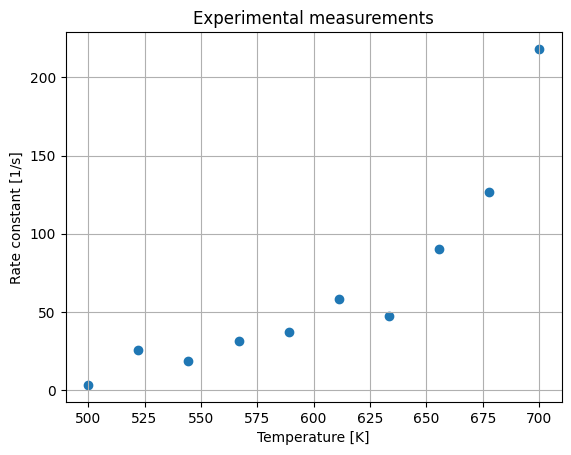

In [ ]:
# Experimental measurements plot
fig, ax = plt.subplots()
ax.scatter(T, k)
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Rate constant [1/s]")
ax.set_title("Experimental measurements")
ax.grid(True)

### Question 2.2: Residual sum of squares

We rewrite the original equation such that we get an equation of the form $y=mx+q$ with $x$ and $y$ new variables depending on the original variables k and T.

For this, we apply the natural logarithm to the Arrhenius equation.

\begin{equation}
\tag{Eq.2}
\ln(k)=-\frac{E_a}{RT}+\ln(A)
\end{equation}

We thus assign the following variables:
- $x$ = $\frac{1}{T}$
- $m$ = $-\frac{E_a}{R}$
- $y$ = $\ln(k)$
- $q$ = $\ln(A)$

You can now proceed by finding the parameters $m$ and $q$ of a generic linear function $y = mx + q$ fitting the data points.

For this, consider a linear regression problem
\begin{equation}
\tag{Eq.3}
RSS(m,q)=\sum_{n=1}^N(y_i-(mx_i+q))^2
\end{equation}
where $i$ corresponds to the individual data points.

Recall: For a generic linear regression problem with parameters $w$, the RSS can be expressed as 
\begin{equation}
\tag{Eq.4}
RSS(w)=(y-Xw)^T(y-Xw)
\end{equation}
with an output matrix $y$ and in input matrix $X$.
Remember that the normal equation 
\begin{equation}
\tag{Eq.5}
w=(X^TX)^{-1}X^Ty
\end{equation}

is the analytical solution to the minimization problem $\min_{w} RSS(w)$.

**Question 2.2.1**

Find a reformulation of our linear regression task in the form of equation 4. Build a matrix variable called `A_m` that represents the term $X^TX$ and a vector called `b_v` that represents the term $X^Ty$.

In [ ]:
# Linear system definition
x = 1/T
y = np.log(k)
X = np.column_stack((x, np.ones_like(x)))  
A_m = X.T@X
b_v = X.T@y

**Question 2.2.2**

Solve the linear system using `np.linalg.solve()` and print the values of the **Arrhenius parameters** A and Ea.

In [ ]:
# Linear system solution and Arrhenius parameters
m, q = np.linalg.solve(A_m, b_v)
R = 8.3145
A = np.exp(q)
Ea = -m*R

print("A: ", A)
print("Ea: ", Ea)

A:  563164.4866819838
Ea:  47022.479747190555


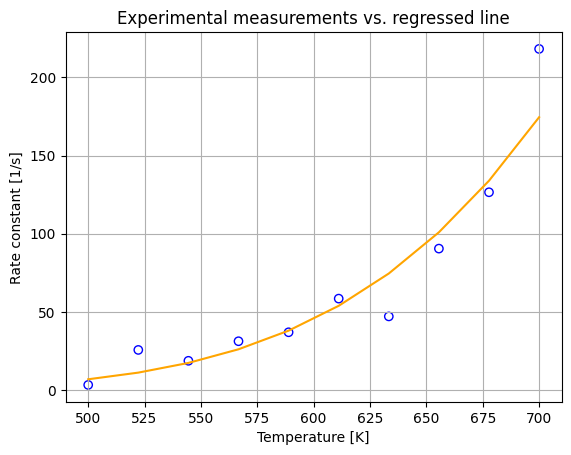

In [ ]:
fig, ax = plt.subplots()
ax.scatter(T, k, facecolors="none", edgecolors="b")
ax.plot(T, A * np.exp(-Ea / R / T), "orange")
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Rate constant [1/s]")
ax.set_title("Experimental measurements vs. regressed line")
ax.grid(True)
plot_Regr = fig, [ax]

## Part 3: Parabolic PDE - Finite Difference with Forward Euler Method

$$
\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}
$$

Simulate the heat diffusion to determine the temperature distribution over time in a one-dimensional rod of length $ L = 1.0 \, \text{m} $ over a total simulation time of $ t_{\text{tot}} = 5.0 \, \text{s} $. The rod is discretized into $ N_x = 101 $ spatial points. The heat equation (above) should be solved numerically using the explicit Euler method and finite differences under the following conditions:

- **Diffusion coefficient**: $ \alpha = 1 \times 10^{-3} \, \text{m}^2/\text{s} $
- **Boundary condition**: A Dirichlet boundary condition $ \bar{T} = 10.0 $ is applied at the midpoint of the rod ($ x = 0.5 \, \text{m} $). The rod is then insulated in the extremity $x=L$ (the flux is equal to zero).
- **Initial condition**: The temperature $ T_0 = 0 $ everywhere in the rod at $ t = 0 $.


**For the spatial discretization, consider every discretization point in the domain (also the boundaries) and do not use ghost points.**

**Remember: There exists also a backward and forward discretization schemes for second order derivatives. The forward scheme might be necessary for this exercise ;)**

---

### Functions to Implement

1. **create_matrix_A(Nx: int, Fo: float) -> np.ndarray**  
   Constructs the coefficient matrix $ A $ for the finite difference scheme.  
   - **Arguments**:  
     - `Nx`: Number of spatial points ($ N_x $).  
     - `Fo`: Fourier number.  
   - **Returns**: Coefficient matrix $ A $ of size $ (N_x, N_x) $.

2. **create_vector_b(Nx: int, temp_bar: float) -> np.ndarray**  
   Creates the vector $ b $ that incorporates the Dirichlet boundary condition.  
   - **Arguments**:  
     - `Nx`: Number of spatial points ($ N_x $).  
     - `temp_bar`: Value of the Dirichlet boundary condition.  
   - **Returns**: Vector $ b $ of size $ N_x $.

3. **forward_euler_method(A: np.ndarray, b: np.ndarray, temp_0: np.ndarray, Fo: float, t_steps: int) -> np.ndarray**  
   Solves the heat diffusion equation using the explicit Euler method.  
   - **Arguments**:  
     - `A`: Coefficient matrix $ A $.  
     - `b`: Vector $ b $.  
     - `temp_0`: Initial condition array ($ T_0 $).  
     - `Fo`: Fourier number.  
     - `t_steps`: Number of time steps.  
   - **Returns**: A 2D array of temperature profiles, where each row corresponds to a time step.  

In [ ]:
# create_matrix_A

def create_matrix_A(Nx: int, Fo:float)->np.ndarray:
    """
    ....
    """
    N = Nx

    A = np.eye(N) * (1/Fo -2)
    A += np.diag(np.ones(N-1),k=-1)
    A += np.diag(np.ones(N-1),k=+1)

    # the start of the tube has no equation for the change in temp --> use the upwind scheme to iqnore the i-1 term 
    A[0,0] = (1 + 1/Fo)
    A[0,1] = -2
    A[0,2] = 1
    
    # setting the middle of the temp to be a constant known value
    A[50, :] = 0
    A[50,50] = 1    # this sets the middle of the tube to have a constant temperature

    # The neuman edge boundary at x=L 
    A[Nx-1, Nx-2] = 2    
    return A

A = create_matrix_A(101, 1)
print(A)

[[ 2. -2.  1. ...  0.  0.  0.]
 [ 1. -1.  1. ...  0.  0.  0.]
 [ 0.  1. -1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -1.  1.  0.]
 [ 0.  0.  0. ...  1. -1.  1.]
 [ 0.  0.  0. ...  0.  2. -1.]]


In [ ]:
# create_vector_b

def create_vector_b(Nx, temp_bar)->np.ndarray:

    b = np.zeros(Nx)

    b[50] = temp_bar
    return b 


In [ ]:
# forward_euler_method
def forward_euler_method(A, b, temp_0, Fo, t_steps)->np.ndarray:

    temp = np.zeros((t_steps, 101))
    temp[0,:] = temp_0
    
    for i in range(1,t_steps):
        temp[i,:] = Fo*(A@temp[i-1,:]+ b)


    return temp


In [ ]:
# Given Parameters
L = 1.0
t_tot = 5.0
Nx = 101
x = np.linspace(0, L, Nx)
dx = x[1] - x[0]
alpha = 1e-3

# Determine the time step according to stability criteria and the number of time steps
"""The stability criteria states that Fo has to be at least 0.5"""

dt = 0.5*dx**2/alpha
t_steps = int((5-0)/dt + 1)

# Determine the Fourier number
Fo = 0.5

# Dirichlet boundary condition
temp_bar = 10

# Create matrix A, vector b, and define given initial condition
A = create_matrix_A(Nx, Fo)
b = create_vector_b(Nx,temp_bar)
temp_0 = 0 

# Solve using the Euler method
temp = forward_euler_method(A,b, temp_0,Fo, t_steps)

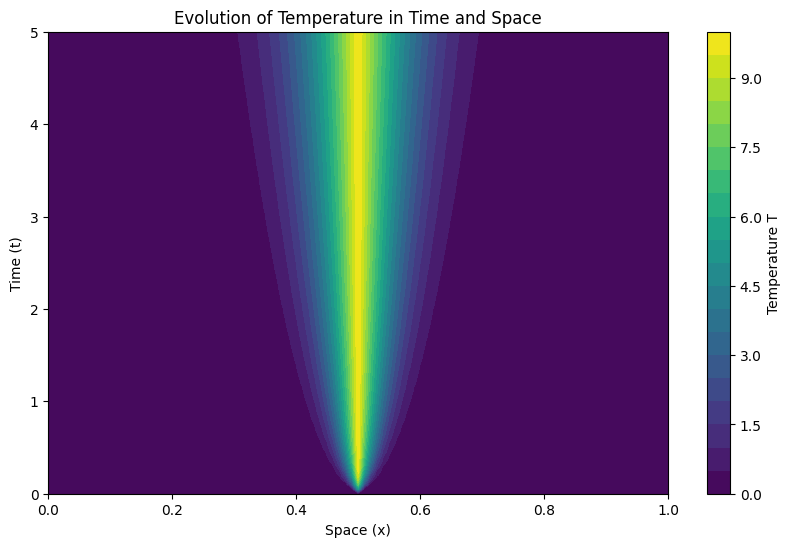

In [ ]:
# Plotting (already implemented)
t = np.linspace(0, t_tot, t_steps)
X, T = np.meshgrid(x, t)
plt.figure(figsize=(10, 6))
plt.contourf(X, T, temp, 20, cmap="viridis")
plt.colorbar(label="Temperature T")
plt.xlabel("Space (x)")
plt.ylabel("Time (t)")
plt.title("Evolution of Temperature in Time and Space")
plt.show()